# Trace Generation and DPA

You are given a set of power traces taken during
AES-ECB executions with the associated input/output values of AES, and
you are asked to extract the 128-bit secret key via Differential Power Analysis
(DPA).

## 1. Download provided files

Package to download Google Drive Folder

In [ ]:
!pip install gdown

In [ ]:
# The folder is (https://drive.google.com/drive/folders/1pPd6e4pJM7x8eoPraKG3YzYTP1fGCtPO)

import gdown

gdown.download_folder(id='1pPd6e4pJM7x8eoPraKG3YzYTP1fGCtPO', quiet=False, use_cookies=False)


Retrieving folder contents


Retrieving folder 19qN7v0O3C8ib9IH66hqpihERKqaHEiZ4 rtl
Processing file 1GQIV2GpiOlHqbAchm3zZUgwgJ-yGVlgx aes128_table_ecb.sv
Retrieving folder 1A9MJC1gSSZqw3UfnX10vaZ-vckNatFSt scripts
Processing file 1mZ5s4BO9XmMQtjgHytD3dvusRhYh5NoT extract_regs.sh
Retrieving folder 1pvKgWN-tHUBb4ejFaO-y5X4YWfys1URl sim
Processing file 1mkAk7va5XLdiFwgSM_BtZmWDA4YgvlzE plaintext_ciphertext_orig_5000.txt
Processing file 1kBaoz72rPq7fcEpqGQ-lz0klQp8ex0WJ plaintext_ciphertext_orig_10000.txt
Processing file 1INNSlG3yYvUYRCcEwRINXqxu-cAspAgx tb_aes128_table_ecb.sv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1GQIV2GpiOlHqbAchm3zZUgwgJ-yGVlgx
To: /content/DPA_AES/rtl/aes128_table_ecb.sv
100%|██████████| 40.9k/40.9k [00:00<00:00, 37.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1mZ5s4BO9XmMQtjgHytD3dvusRhYh5NoT
From (redirected): https://drive.google.com/uc?id=1mZ5s4BO9XmMQtjgHytD3dvusRhYh5NoT&confirm=t&uuid=359019b3-1d0c-4d61-ac1a-069cee81cea3
To: /content/DPA_AES/scripts/extract_regs.sh
100%|██████████| 622/622 [00:00<00:00, 1.71MB/s]
Downloading...
From: https://drive.google.com/uc?id=1mkAk7va5XLdiFwgSM_BtZmWDA4YgvlzE
To: /content/DPA_AES/sim/plaintext_ciphertext_orig_5000.txt
100%|██████████| 330k/330k [00:00<00:00, 86.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1kBaoz72rPq7fcEpqGQ-lz0klQp8ex0WJ
To: /content/DPA_AES/sim/plaintext_ciphertext_orig_10000.txt
100%|██████████| 660k/660k [00:00<00:00,

['/content/DPA_AES/rtl/aes128_table_ecb.sv',
 '/content/DPA_AES/scripts/extract_regs.sh',
 '/content/DPA_AES/sim/plaintext_ciphertext_orig_5000.txt',
 '/content/DPA_AES/sim/plaintext_ciphertext_orig_10000.txt',
 '/content/DPA_AES/sim/tb_aes128_table_ecb.sv']

## 2. Directory Structure

Directory Structure:

```
> DPA_AES
  > rtl
  > scripts
  > sim
```

- ```DPA_AES``` is the parent folder, which contains 3 sub-folders.
  - ```rtl```
    - This subfolder contains the Verilog RTL model of AES-128 (```aes128_table_ecb.sv```).
  - ```scripts```
    - This contains a Bash script to extract all the registers in the simulation VCD file.
  - ```sim```
    - This subfolder contains the testbench for the AES-128 RTL (```tb_aes128_table_ecb.sv```).
    - It also contains the plaintext and ciphertext raw files. These are in ```plaintext_ciphertext_orig_5000.txt``` (which contains 5000 plaintext and cipher text combinations), and ```plaintext_ciphertext_orig_10000.txt``` (which contains 10000 plaintext and cipher text combinations).



## 3. Trace Generation

---

### 3.1 iVerilog: A Verilog Simulator

iVerilog is an open-source Verilog simulator that allows you to simulate and test your hardware designs written in the Verilog Hardware Description Language (HDL). It's a valuable tool for verifying the functionality of your circuits before physical implementation.

**Key Features:**

* **Open-source:**  Freely available and modifiable.
* **Verilog Support:** Supports various Verilog standards, including SystemVerilog.
* **Simulation Capabilities:** Enables functional simulation of digital circuits.
* **Debugging:** Provides debugging tools to identify and fix errors in your designs.

**Common Use Cases:**

* **Verification:**  Test your HDL code for correctness and functionality.
* **Prototyping:**  Simulate hardware designs before implementing them in hardware.
* **Education:**  Learn and practice Verilog coding and simulation.

#### 3.1.1 Install iVerilog

In [ ]:
!apt update && apt install -y iverilog


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,742 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,984 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages 

#### 3.1.2 Simulation Commands

Input Files

In [ ]:
RTL_File = "DPA_AES/rtl/aes128_table_ecb.sv"
SIM_File = "DPA_AES/sim/tb_aes128_table_ecb.sv"

-o : output file,
-g : verilog version

In [ ]:
!iverilog -g2012 -o aes.out $RTL_File $SIM_File
!vvp aes.out > output.txt

/bin/bash: line 1: iverilog: command not found
/bin/bash: line 1: vvp: command not found


### 3.2 VCD Parsing

#### 3.2.1 Run the regex script to extract registers from VCD File

Script and VCD File

In [ ]:
Regex_File = "DPA_AES/scripts/extract_regs.sh"
VCD_File = "waveform.vcd"

Output File

In [ ]:
Filtered_Reg_File = "register_file.txt"

Run the Script

In [ ]:
#Convert the regex script to be executable
!chmod +x $Regex_File

#Extract Registers based on "reg field" in the vcd file and store in a text file
"""
  Script: extract_regs.sh
  Input File: waveform.vcd
  Output File: register_file.txt
"""
!$Regex_File $VCD_File $Filtered_Reg_File

DPA_AES/scripts/extract_regs.sh: line 11: $output_vcd_file: ambiguous redirect
awk: cannot open waveform.vcd (No such file or directory)


#### 3.2.2 Extracting Register Names

In [ ]:
import re

def extract_register_names(filename="register_file.txt"):
    """
      Input: register_file.txt
      Output: list of register names
      Description: Extracts each word in the file and adds it to a list
    """
    register_names = []
    try:
        with open(filename, 'r') as file:
            for line in file:
                match = re.search(r"\b(\w+)\b", line) # Matches any whole word

                if match:
                    register_name = match.group(1)
                    register_names.append(register_name)
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    return register_names

register_list contains a list of all the register names extracted by the regex script.

In [ ]:
register_list = extract_register_names(Filtered_Reg_File)

#### 3.2.3 Extracting Register VCD

Install required Packages

In [ ]:
!pip install vcdvcd matplotlib

Import Necessary Packages

In [ ]:
import matplotlib.pyplot as plt
from vcdvcd import VCDVCD

Parse the vcd file

In [ ]:
# Load the VCD file
vcd = VCDVCD(VCD_File)

# Extract available signals
signals = list(vcd.signals)

In [ ]:
# Use a regular expression to find signals with any value from register_list in their name
def find_matching_signals(signals, register_list):
    """
      Input: signals
             register_list
      Output: list of matching signals
      Description: Finds signals with any value from register_list in their name
    """
    matching_signals = []
    for signal in signals:
        for register in register_list:
            if register in signal:
                #Skipping custom signals used as counters
                if "tb_aes128_table_ecb.dut.itemp" not in signal and "tb_aes128_table_ecb.dut.temp" not in signal:
                  matching_signals.append(signal)
                break # Avoid adding the same signal multiple times if multiple registers match
    return matching_signals

Find register names and match with vcd file

In [ ]:
matching_signals = find_matching_signals(signals, register_list)

Creating Text file with register info

In [ ]:
# Dump matching_signals to a text file
with open("matching_signals.txt", "w") as f:
    for signal in matching_signals:
        f.write(signal + "\n")

### 3.3 Hamming Distance Multi-Trace Generation

Hamming Distance Power Model

In [ ]:
def compute(prev_value,current_value,HD=True):
    """
      Input: prev_value
              current_value
              hw
      Output: hamming_diff
      Description: Computes the hamming distance between two integers (if HD)
                    or returns the hamming weight value (if not HD)
    """
    diff = 0
    if HD:
      diff = prev_value ^ current_value
    else:
      diff = current_value

    hamming_diff = diff.bit_count()

    return hamming_diff

Compute Power for each Register

In [ ]:
import numpy as np
from collections import defaultdict

# Dictionary to store the Hamming distance traces for each signal
hamming_diff_traces = {}

# List to store total Hamming distance traces (each entry is a separate trace)
total_hamming_diff_traces = []

# Iterate through matching signals
for signal in matching_signals:
    signal_values = vcd[signal].tv  # Extract signal values over time
    traces = []          # List to store split traces for this signal
    current_trace = []   # Current trace segment
    prev_value = None    # Previous integer value for computing Hamming distance

    for t, v in signal_values:
        # Note: 'x' occurs at dumpoff, so split trace on encountering 'x'
        if 'x' in str(v):
            if current_trace:  # Save the current trace if it has data
                traces.append(current_trace)
                current_trace = []  # Reset for a new trace
            prev_value = None  # Reset previous value for a new trace segment
        else:
            # Convert value to integer
            int_value = int(v,2)
            if prev_value is None:
                # First value in a trace: no previous value so distance is 0
                hamming_diff = 0
            else:
                # Compute Hamming distance as the number of differing bits
                hamming_diff = compute(prev_value, int_value, True)

            prev_value = int_value  # Update previous value

            # Append the (time, Hamming distance) to the current trace
            current_trace.append((t, hamming_diff))

    # Save the last trace if it has data
    if current_trace:
        traces.append(current_trace)

    # Store traces for the current signal
    hamming_diff_traces[signal] = traces

Combine (sum) individual signals into global total traces

In [ ]:
# Determine the maximum number of trace segments across all signals.
max_traces = max(len(traces) for traces in hamming_diff_traces.values())

# Create a list of global total traces.
# Each element is a defaultdict (keyed by timestamp) that will accumulate Hamming distances.
total_hamming_diff_traces = [defaultdict(int) for _ in range(max_traces)]

# For each signal, add its trace segment values to the corresponding global trace.
for signal, traces in hamming_diff_traces.items():
    for i, trace in enumerate(traces):
        for t, diff in trace:
            total_hamming_diff_traces[i][t] += diff

# Convert each global trace dictionary into sorted lists for plotting.
global_traces = []
for trace_dict in total_hamming_diff_traces:
    sorted_timestamps = sorted(trace_dict.keys())
    sorted_diffs = [trace_dict[t] for t in sorted_timestamps]
    global_traces.append((sorted_timestamps, sorted_diffs))

### 3.4 Interpolating Generated Trace

UnivariateSpline

In [ ]:
from scipy.interpolate import UnivariateSpline
# List to store interpolated global traces
# Each element is a tuple: (new_timestamps, new_diffs)
interpolated_global_traces = []

# Iterate over all traces in global_traces to interpolate them
for timestamps, diffs in global_traces[0:-1]:
    # Set a smoothing factor based on variance and number of points (adjust as needed)
    smoothing_factor = 0.1 * np.var(diffs) * len(timestamps)

    # Create the smoothing spline for the current trace
    spline = UnivariateSpline(timestamps, diffs, s=smoothing_factor)

    # Create a new, evenly spaced time axis for interpolation (e.g., 1000 points)
    new_timestamps = np.linspace(min(timestamps), max(timestamps), 1000)
    new_diffs = spline(new_timestamps)

    # Store the interpolated results
    interpolated_global_traces.append((new_timestamps, new_diffs))

Dumping interpolated traces as a CSV

In [ ]:
Trace_File = "interpolated_traces_no_timestamps.csv"

In [ ]:
import csv

# Prepare data for CSV
csv_data = []
for timestamps, diffs in interpolated_global_traces:
    csv_data.append(diffs)  # Only diffs as no timestamps required

# Write to CSV
with open(Trace_File, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(csv_data)


### 3.5 Observing Hamming Distance of a signal

Choose the Signal you would like to plot! \
Tip: matching_signals.txt has the names of sigals you would be interested in


In [ ]:
signal_to_plot = 'tb_aes128_table_ecb.clk_reg'

Plotting Hamming Distance of Chosen Signal

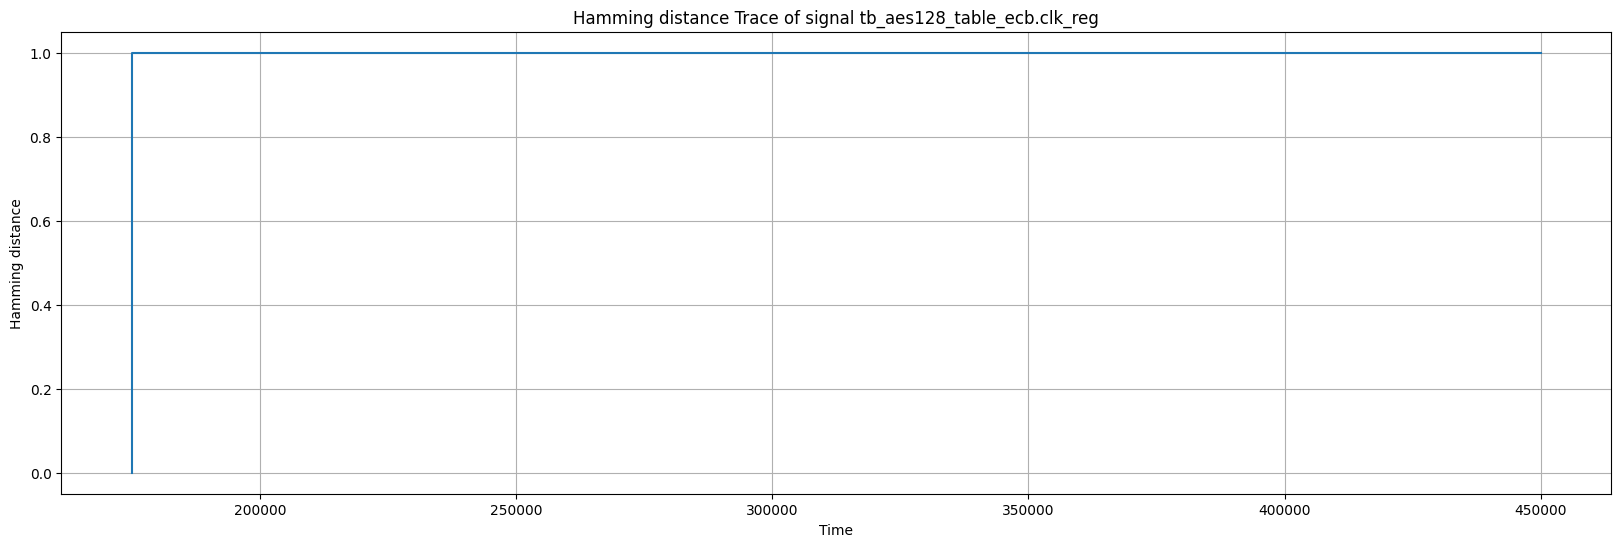

In [ ]:
times, weights = zip(*hamming_diff_traces[signal_to_plot][0])
plt.figure(figsize=(20, 6))
plt.step(times, weights)
plt.xlabel("Time")
plt.ylabel("Hamming distance")
plt.title(f"Hamming distance Trace of signal {signal_to_plot}")
plt.grid(True)
plt.show()

## 4. DPA

---

### Importing Power Trace

In [ ]:
import pandas as pd
df = pd.read_csv(Trace_File,header=None)

### Importing CipherText and PlainText

lines is a list containing plaintext values

lines2 is a list containing ciphertext values.

In [ ]:
lines = []
lines2 = []
with open('DPA_AES/sim/plaintext_ciphertext_orig_5000.txt', 'r') as f:
    for line in f:
        plaintext, ciphertext = line.strip().split('_')
        lines.append(plaintext)
        lines2.append(ciphertext)

### Trace Overview

Waveform for 1 AES Encryption

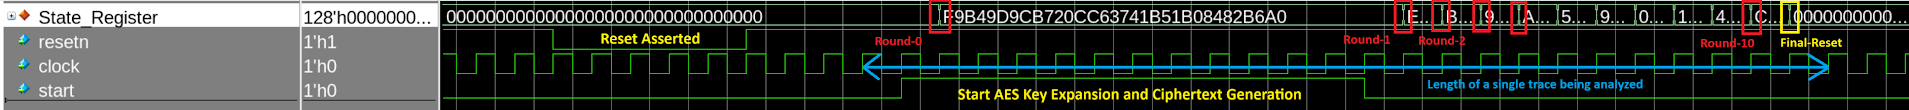

Note: Right click on the image and open in new tab for a larger view

### Assignment

Plot the first power trace, corresponding to the first encryption
operation.

Analyze the provided power trace. What are the peaks in the
trace? \

Hint: Compare the trace against the waveform above to see what the peaks correspond to.

Before we proceed to DPA, think of a good pre-processing step to make the attack more successful. \
 Hint: Plot the first few
power traces and think how to better align them.

Let's execute the DPA attack using Pearson's correlation test. First, think of
an easy target operation for the DPA and, second, consider the number of bits
to be estimated by DPA at a time.

What is a good power model for the target operation? Justify
it. Feel free to try out different power models before you commit to one.

Note: Feel free to use either Hamming Weight or Distance \
Change the call to compute function accordingly in section 3.3

Apply the DPA on the first byte of the key, plot the results Figure 2 for
all key guesses.
Find the maximum correlation (consider both positive and negative peaks)
and plot the two best key guesses Figure 3 that have the maximum likelihood.

Apply the DPA on the entire key. What is the 128-bit AES
secret key? Note that not all key values could be 100% detected depending on
your targeted computation, i.e. there can be false positives. If this is the case,
you may need to take the first n possible results and apply a brute-force search
within these reduced search space. Hint: Targeting the initialization may
especially cause this behavior, targeting computations after the initialization
might be a better idea. You can also try the partition-based tests (With
difference of means) to extract the key.


## Hints for Attacking Last Round [Key Byte 0]
---



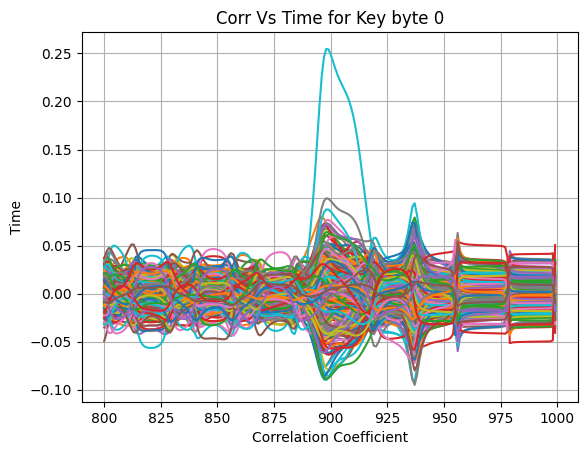

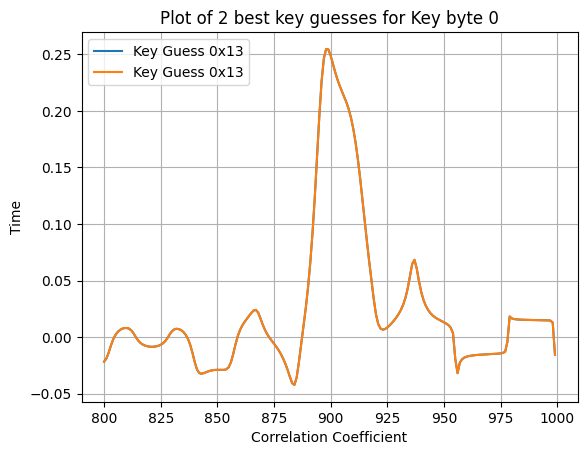

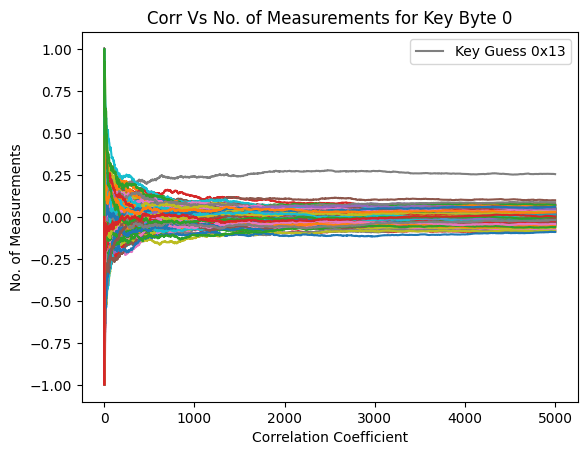